<a href="https://colab.research.google.com/github/Uzmamushtaque/CSCI_4170_6170_Spring2026/blob/main/Lecture_11_Modern_LLM_Design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lecture 11: Architecture, Scaling, and Data for Modern LLMs

> **Key Idea:** how transformer design, compute scaling, and training data quality interact to shape large language model performance.

This notebook synthesizes the attached lecture materials into a single, cleaner narrative.  
It is designed to function as a **lecture notebook**: readable as notes, presentable in class, and runnable in parts.

## Learning Objectives

By the end of this lecture, students should be able to:

1. Distinguish **encoder-only**, **decoder-only**, and **encoder–decoder** transformer families.
2. Explain why **decoder-only models** became dominant for open-ended generation.
3. Describe what **scaling laws** mean in LLM training and why **compute-optimal scaling** matters.
4. Explain why **data quality, diversity, and curation** matter just as much as model size.
5. Connect architecture choices, training compute, and dataset design into a single training strategy.

---

## Roadmap

1. Transformer architecture variants  
2. Scaling laws and compute-optimal training  
3. Training data for larger LLMs  
4. Putting everything together: how practitioners make design decisions


## 1. Big Picture

Modern LLM development is not just a story of “bigger models.”

A strong model comes from the interaction of **three decisions**:

- **Architecture:** What kind of transformer are we building?
- **Scaling strategy:** How do we allocate compute between parameters, tokens, and training time?
- **Data pipeline:** What data do we train on, how do we clean it, and how do we keep it useful and safe?

A practical mental model is:

$$
  \text{Model quality} \approx f(\text{architecture}, \text{compute}, \text{data})
$$

If any one of these is weak, the overall system underperforms.


## 2. Review: The Original Transformer

The original Transformer introduced in **“Attention Is All You Need”** used an **encoder–decoder** design.

### Encoder
- Processes the full input sequence in parallel
- Builds contextual representations with self-attention and feedforward layers
- Best thought of as the **understanding** side of the architecture

### Decoder
- Generates output tokens autoregressively, one step at a time
- Uses masked self-attention so tokens cannot look ahead
- Can attend to encoder outputs through cross-attention
- Best thought of as the **generation** side of the architecture

### Why this mattered
The Transformer replaced recurrence with attention, enabling:
- more parallelism,
- stronger long-range dependency modeling,
- and a new foundation for modern NLP.

---

### A useful question
Once the original encoder–decoder design worked well, researchers asked:

> **Do we always need both halves?**

That question led to the main architecture families used today.



## 3. Main Architecture Families

### A. Encoder-only models
Examples: **BERT, RoBERTa, DistilBERT, SBERT**

**Core idea:** keep the encoder, remove the decoder.

**Training style**
- Typically trained with **masked language modeling (MLM)**
- Learns rich contextual representations using both left and right context

**Strengths**
- Excellent for **classification**, **retrieval**, **ranking**, **feature extraction**, and **sentence embeddings**
- Efficient when you need a representation of text, not free-form generation

**Limitations**
- Not naturally suited for long-form autoregressive generation

---

### B. Decoder-only models
Examples: **GPT family, LLaMA family, Mistral, Falcon**

**Core idea:** keep the decoder, remove the encoder.

**Training style**
- Trained autoregressively: predict the **next token** from previous tokens
- Uses **causal attention**

**Strengths**
- Excellent for **open-ended text generation**
- Flexible enough for dialogue, coding, summarization, reasoning, and instruction following
- Scales especially well with data and compute

**Limitations**
- Less naturally optimized for tasks that primarily need fixed embeddings

---

### C. Encoder–decoder models
Examples: **T5, Flan-T5, BART, mBART**

**Core idea:** keep the full sequence-to-sequence design.

**Training style**
- Often framed as **text-to-text**
- Useful when the task clearly maps an input sequence to an output sequence

**Strengths**
- Strong for **translation**, **summarization**, and structured transformation tasks
- Can unify many NLP tasks under one interface

**Limitations**
- More computationally complex than single-stack designs
- Has become less dominant for general-purpose chat generation

---

### D. Newer variants
Examples: **Mixture-of-Experts (MoE), multimodal transformers**

These variants modify the base recipe to improve:
- capacity,
- efficiency,
- or modality coverage (text + image + audio + more).


In [ ]:

import pandas as pd

family_df = pd.DataFrame(
    [
        {
            "Family": "Encoder-only",
            "Attention pattern": "Bidirectional self-attention",
            "Pretraining objective": "Masked language modeling",
            "Best for": "Embeddings, classification, retrieval",
            "Example models": "BERT, RoBERTa, SBERT",
        },
        {
            "Family": "Decoder-only",
            "Attention pattern": "Causal / unidirectional self-attention",
            "Pretraining objective": "Next-token prediction",
            "Best for": "Generation, chat, coding, long-form text",
            "Example models": "GPT, LLaMA, Mistral",
        },
        {
            "Family": "Encoder–decoder",
            "Attention pattern": "Encoder self-attention + decoder masked self-attention + cross-attention",
            "Pretraining objective": "Seq2seq / text-to-text objectives",
            "Best for": "Translation, summarization, transformation tasks",
            "Example models": "T5, Flan-T5, BART",
        },
        {
            "Family": "MoE / Multimodal variants",
            "Attention pattern": "Transformer core with routing or multi-modal components",
            "Pretraining objective": "Task- and system-specific",
            "Best for": "Efficient scaling or mixed modality reasoning",
            "Example models": "Switch Transformer, GLaM, GPT-4V-style systems",
        },
    ]
)

family_df


,Family,Attention pattern,Pretraining objective,Best for,Example models
0,Encoder-only,Bidirectional self-attention,Masked language modeling,"Embeddings, classification, retrieval","BERT, RoBERTa, SBERT"
1,Decoder-only,Causal / unidirectional self-attention,Next-token prediction,"Generation, chat, coding, long-form text","GPT, LLaMA, Mistral"
2,Encoder–decoder,Encoder self-attention + decoder masked self-a...,Seq2seq / text-to-text objectives,"Translation, summarization, transformation tasks","T5, Flan-T5, BART"
3,MoE / Multimodal variants,Transformer core with routing or multi-modal c...,Task- and system-specific,Efficient scaling or mixed modality reasoning,"Switch Transformer, GLaM, GPT-4V-style systems"



## 4. Encoder-only Models in More Detail

### BERT-style models
BERT changed NLP by showing that **deep bidirectional context** can produce highly useful text representations.

Two classic pretraining objectives are:

1. **Masked Language Modeling (MLM)**  
   Randomly mask some tokens and train the model to predict them.

2. **Next Sentence Prediction (NSP)**  
   Predict whether one sentence follows another.

Later models such as **RoBERTa** removed NSP and focused on stronger training data and better optimization.  
Smaller derivatives such as **DistilBERT** traded some accuracy for faster inference and lower memory cost.

### SBERT vs Cross-Encoders

A helpful retrieval distinction:

- **SBERT** encodes each sentence independently into embeddings, then compares them with cosine similarity.
- **Cross-encoders** feed both texts together, allowing full attention across the pair and usually yielding better ranking accuracy.

**Trade-off**
- Use **SBERT** when you need speed and scalable retrieval.
- Use a **cross-encoder** when you need higher-quality reranking.



## 5. Why Decoder-only Models Took Over

Decoder-only models became the dominant paradigm because they align extremely well with the task:

> **Generate the next token, then repeat.**

That simple training objective turns out to be very powerful.

### Why industry favored decoder-only systems
1. **Autoregressive generation matches the user experience**  
   Chatbots, coding assistants, and content generation all require token-by-token generation.

2. **General-purpose behavior emerges at scale**  
   With enough parameters, data, and compute, a single model can do many tasks from prompting alone.

3. **Scaling works well**  
   Empirical scaling laws showed that larger autoregressive models trained properly can keep improving.

4. **Instruction tuning and alignment made them usable**  
   Raw next-token models became much more helpful once fine-tuned for following instructions and aligned with human preferences.

### Important nuance
Decoder-only models are not “better at everything.”  
Encoder-style systems still matter for embeddings, search, and ranking.  
The real point is that decoder-only models became the most flexible **general-purpose** interface.



## 6. Encoder–Decoder Models Still Matter

Even though decoder-only LLMs dominate general-purpose generation, encoder–decoder systems remain important.

### T5
T5 reframed many tasks as:
- input text → output text

That made translation, summarization, QA, and classification look like one unified problem.

### Flan-T5
Flan-T5 pushed this further using **instruction tuning**, improving zero-shot and few-shot performance.

### When this family is a good fit
Encoder–decoder models are often attractive when:
- the task is explicitly **sequence-to-sequence**,
- the input and output roles are clearly separated,
- or you want a clean text-to-text training setup.

### Why they became less dominant
Maintaining both an encoder and a decoder costs more memory and compute than a single-stack architecture.  
As decoder-only models improved, many general-purpose use cases shifted toward them.



## 7. Beyond Dense Transformers: MoE and Multimodality

### Mixture of Experts (MoE)
MoE models increase total parameter count without activating every parameter for every token.

**Key idea**
- A router chooses which expert subnetworks handle a given token.
- Only a subset of the model is active on each forward pass.

**Why this is attractive**
- More capacity without a proportional increase in compute per token
- Useful for scaling to very large systems

**Challenges**
- Load balancing across experts
- More complex training and deployment
- More demanding systems engineering

---

### Multimodal models
These models process more than text, such as:
- text + image,
- text + audio,
- or text + image + speech.

Examples mentioned in the lecture materials include:
- **CLIP**
- **Flamingo**
- **PaLI**
- **GPT-4V-style systems**
- **Whisper**
- **MM1**

The main idea is that the transformer backbone becomes a **general sequence processor**, not just a text model.



## 8. Scaling Laws: What They Mean

Scaling laws describe how model performance changes as we increase resources like:
- model size,
- dataset size,
- and compute.

In LLMs, a core empirical finding is that loss often decreases approximately according to a power law:

\[
L(C) \approx A C^{-\alpha} + B
\]

where:
- \(C\) is compute,
- \(\alpha\) is a scaling exponent,
- and \(A, B\) are constants fit from data.

### Why this matters
Scaling laws give practitioners a way to reason before training:

- How much performance gain should we expect from more compute?
- Is it better to add parameters or tokens?
- Are we wasting resources with a poorly balanced setup?

This was a major shift from “train and hope” to a more principled design process.


Matplotlib is building the font cache; this may take a moment.


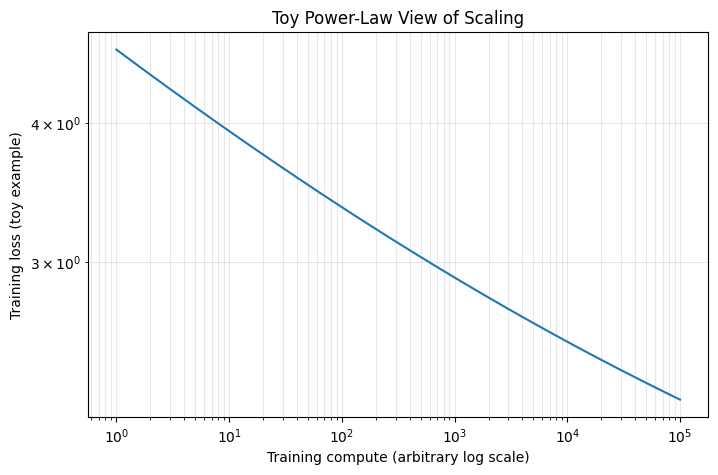

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

compute = np.logspace(0, 5, 200)
toy_loss_curve = 3.5 * compute**(-0.10) + 1.15

plt.figure(figsize=(8, 5))
plt.loglog(compute, toy_loss_curve)
plt.xlabel("Training compute (arbitrary log scale)")
plt.ylabel("Training loss (toy example)")
plt.title("Toy Power-Law View of Scaling")
plt.grid(True, which="both", alpha=0.3)
plt.show()



### Interpreting the plot

This plot is only a **toy illustration**, but it captures the central intuition:

- More compute usually helps.
- The gains are **predictable** for a while.
- The curve flattens, so each extra unit of compute buys less improvement than before.

That is why **efficient allocation** matters so much.



## 9. Compute-Optimal Scaling

A major lesson from scaling work is that it is inefficient to scale only one thing.

### Bad pattern 1: too many parameters, not enough data
If the model is very large but the dataset is too small:
- the model cannot fully use its capacity,
- overfitting becomes more likely,
- and compute is wasted.

### Bad pattern 2: too much data, not enough model capacity
If the dataset grows but the model is too small:
- the model cannot absorb all the useful structure,
- and performance saturates early.

### Compute-optimal idea
For a fixed budget, the goal is to choose a **balanced combination** of:
- parameter count,
- number of training tokens,
- and training duration.

The lecture materials highlight a major modern insight:
> Under a fixed compute budget, training on **more tokens with a better-sized model** can outperform simply making the model much larger.

This is the logic behind **Chinchilla-style scaling** and helps explain why later systems emphasized **training longer on more high-quality data**, not just increasing parameter count.


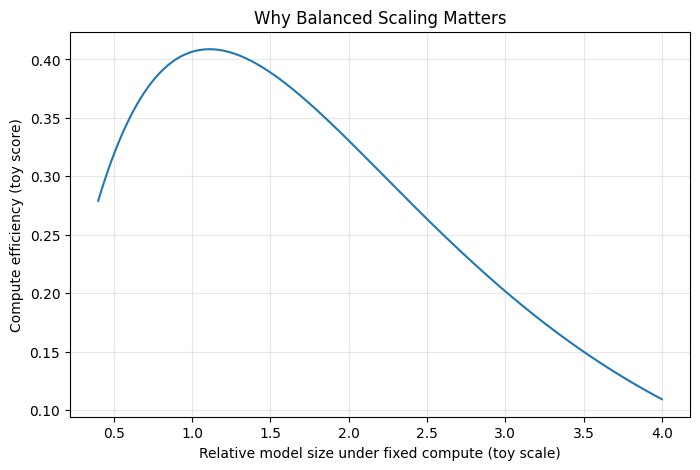

In [ ]:

ratios = np.linspace(0.4, 4.0, 200)
# Toy proxy for "efficiency" under a fixed compute budget.
# Peak in the middle means both under-scaling and over-scaling are bad.
efficiency = ratios * np.exp(-0.9 * ratios)

plt.figure(figsize=(8, 5))
plt.plot(ratios, efficiency)
plt.xlabel("Relative model size under fixed compute (toy scale)")
plt.ylabel("Compute efficiency (toy score)")
plt.title("Why Balanced Scaling Matters")
plt.grid(True, alpha=0.3)
plt.show()



## 10. Emergent Abilities at Scale

One of the most interesting observations in LLM development is that some capabilities become much more visible only after models cross certain scales.

Examples highlighted in the lecture materials include:

- **zero-shot and few-shot learning**
- **better arithmetic and multi-step reasoning**
- **improved summarization and translation**
- **code generation**
- **chain-of-thought-style intermediate reasoning behavior**

### Why this is important
These behaviors suggest that scale changes not only *how well* a model performs, but sometimes *what kinds of behavior become available at all*.

### A careful interpretation
It is helpful to think of emergence not as “magic,” but as a sign that:
- larger models learn richer internal representations,
- more data improves generalization,
- and attention-based architectures can compose information in more flexible ways.



## 11. Training Data: Diversity, Quality, and Quantity

A common mistake is to focus only on parameter counts.  
But the lecture materials make a stronger point:

> **High-performing LLMs require data that is not only large, but also diverse, clean, and useful.**

### Diversity
A diverse corpus helps a model generalize across:
- domains,
- languages,
- dialects,
- and writing styles.

This reduces overfitting to dominant topics or linguistic patterns.

### Quality
High-quality data improves:
- coherence,
- factual reliability,
- and general usability.

Poor-quality data introduces:
- spam,
- broken text,
- misinformation,
- duplicated passages,
- and noisy formatting.

### Quantity
Large models need a lot of tokens to generalize well.  
However, more data is only helpful if the data remains valuable.

So the right rule is:

\[
\text{Good training data} = \text{quantity} + \text{quality} + \text{diversity}
\]

—not quantity alone.



## 12. The Data Curation Pipeline

A practical LLM data pipeline usually looks like this:

### 1. Sourcing
Collect data from:
- web pages,
- books,
- code,
- academic writing,
- government documents,
- community text,
- OCR outputs,
- speech transcripts,
- and other curated corpora.

### 2. Cleaning
Remove:
- broken encoding,
- malformed text,
- boilerplate,
- junk formatting,
- and obviously low-quality content.

### 3. Deduplication
Remove exact and near-duplicate content to avoid:
- memorization of repeated passages,
- inefficient training,
- and distorted data distributions.

### 4. Filtering
Apply quality, safety, and policy filters for:
- toxicity,
- hate speech,
- misinformation,
- privacy leaks / PII,
- and other harmful or irrelevant content.

### 5. Tokenization
Convert text into model-ready token sequences using methods such as:
- **BPE**
- **WordPiece**
- **SentencePiece**

### 6. Storage and access
Use scalable storage and streaming formats so large clusters can train efficiently.

---

### Key lesson
Raw internet text is not “ready-made training data.”  
It becomes useful only after careful engineering and curation.


In [ ]:

import re

raw_samples = [
    "Breaking news!!! click here click here click here",
    "Transformers use attention to model relationships in sequences.",
    "Transformers use attention to model relationships in sequences.",
    "BERT learns bidirectional representations from masked language modeling.",
    "bad encoding \x00\x00 with noise ###",
    "LLaMA-style models are decoder-only and trained with next-token prediction.",
]

def clean_text(text):
    text = re.sub(r"click here", "", text, flags=re.IGNORECASE)
    text = re.sub(r"[^\x20-\x7E]", " ", text)
    text = re.sub(r"#+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned = [clean_text(x) for x in raw_samples]
deduped = list(dict.fromkeys(cleaned))

summary = pd.DataFrame(
    {
        "Stage": ["Raw samples", "After cleaning", "After deduplication"],
        "Count": [len(raw_samples), len(cleaned), len(deduped)],
        "Examples": [
            raw_samples[:2],
            cleaned[:2],
            deduped[:2],
        ],
    }
)

summary


,Stage,Count,Examples
0,Raw samples,6,[Breaking news!!! click here click here click ...
1,After cleaning,6,"[Breaking news!!!, Transformers use attention ..."
2,After deduplication,5,"[Breaking news!!!, Transformers use attention ..."



## 13. Data Quality and Safety: A Real Trade-off

Filtering harmful content is necessary, but it is not trivial.

### Under-filtering risks
- harmful stereotypes,
- toxic generation,
- unsafe outputs,
- legal and regulatory concerns.

### Over-filtering risks
- loss of linguistic diversity,
- removal of important edge cases,
- suppression of marginalized voices or domain-specific language,
- weaker robustness on sensitive topics.

### Best practice
A layered pipeline often works best:
1. heuristic filters,
2. model-based classifiers,
3. human review for high-risk cases,
4. post-training alignment and safety work.

So the goal is not “filter everything risky.”  
The goal is to create a dataset that is both **useful and responsible**.



## 14. Tokenization and Storage

### Why tokenization matters
LLMs do not train directly on raw words.  
They train on token sequences.

The tokenization scheme affects:
- vocabulary size,
- sequence length,
- multilingual behavior,
- and efficiency.

### Common methods
- **BPE (Byte Pair Encoding)**: merges common symbol pairs into subword units
- **WordPiece**: similar idea, widely associated with BERT-style models
- **SentencePiece**: works well without predefined whitespace boundaries and is useful for multilingual settings

### Why storage matters too
At LLM scale, data engineering becomes a core ML problem.

You must support:
- sharding,
- fast streaming,
- parallel loading,
- and reliable reproducibility.

A model is only as trainable as its data pipeline is stable.



## 15. Data Scarcity and Synthetic Data

As models get larger, high-quality human-written text becomes a bottleneck.

### Synthetic data can help by:
- expanding scarce domains,
- covering underrepresented styles or languages,
- and reducing dependence on sensitive or copyrighted material.

### But synthetic data also introduces risks:
- factual errors,
- style homogenization,
- self-reinforcing model biases,
- and **model collapse** if future systems are trained too heavily on earlier model outputs.

### Practical takeaway
Synthetic data is best treated as a **supplement**, not a total replacement for high-quality human-generated corpora.



## 16. Open vs Proprietary Data

There is a major strategic difference between open and proprietary datasets.

### Open or licensed-accessible sources
**Advantages**
- more transparent,
- easier to inspect,
- more reproducible for research,
- useful for open science and benchmarking.

**Challenges**
- may be smaller,
- may contain gaps,
- and may still require extensive cleaning.

### Proprietary sources
**Advantages**
- often higher quality or more specialized,
- may provide a strong competitive edge,
- can support domain-specific performance gains.

**Challenges**
- limited transparency,
- reproducibility problems,
- ethical and legal questions,
- and unequal access across researchers.

This is one reason that reproducing frontier LLMs is difficult:  
the data recipe is often as important as the architecture.



## 17. Putting It All Together: A Design Recipe

Suppose you are building a new language model.  
A strong planning sequence would be:

### Step 1: Define the task
- Embeddings and retrieval? → consider encoder-style methods
- Open-ended generation? → decoder-only is usually the default
- Input-to-output transformation? → encoder–decoder may fit well

### Step 2: Choose a scaling strategy
- Decide how compute will be split between parameters and tokens
- Avoid wasting budget on unbalanced scaling
- Expect diminishing returns and plan accordingly

### Step 3: Build the data recipe
- Source diverse text
- Deduplicate aggressively
- filter harmful / low-quality material
- tokenize consistently
- store data in a scalable training format

### Step 4: Revisit the whole system
Architecture, scale, and data should be tuned together—not independently.

That is the central systems lesson of this lecture.



## 18. Quick Comparison Summary

| Question | Strong default answer |
|---|---|
| Need a sentence embedding or retrieval model? | Encoder-only / SBERT-style |
| Need a chat or coding assistant? | Decoder-only |
| Need translation or structured text-to-text conversion? | Encoder–decoder |
| Need huge capacity without dense-per-token compute? | Consider MoE |
| Need strong performance under fixed compute? | Use compute-optimal scaling |
| Need a better model without just increasing params? | Improve data quality and token budget |



## 19. Check Your Understanding

1. Why are decoder-only models especially well suited to chat and long-form generation?
2. Why can a larger model still perform poorly if it is trained on too little data?
3. What is the difference between **data quantity** and **data quality** in LLM training?
4. Why is deduplication an important step in a large-scale corpus pipeline?
5. In what situations would you choose an encoder–decoder model instead of a decoder-only model?
6. Why can synthetic data be helpful, and why can it also be dangerous?

These questions can be used directly for discussion, a short written reflection, or an exit ticket.



## 20. Key Takeaways

- Transformer research split into multiple model families because different tasks benefit from different architectural biases.
- **Encoder-only** models are strong for understanding and embeddings.
- **Decoder-only** models dominate general-purpose generation because next-token prediction scales extremely well.
- **Encoder–decoder** models still matter for structured seq2seq tasks.
- Scaling laws showed that performance improves predictably, but only when **model size, data size, and compute are balanced**.
- Better data curation often matters as much as bigger models.
- Modern LLM development is fundamentally a **systems problem** spanning architecture, optimization, and data engineering.



## 21. Suggested Readings and Source Material

### Core papers and resources mentioned in the lecture materials
- **Attention Is All You Need**  
  https://arxiv.org/abs/1706.03762

- **BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding**  
  https://arxiv.org/pdf/1810.04805

- **Sentence-BERT**  
  https://arxiv.org/abs/1908.10084

- **Scaling Laws for Neural Language Models**  
  https://arxiv.org/pdf/2001.08361

- **Language Models are Few-Shot Learners (GPT-3)**  
  https://arxiv.org/pdf/2005.14165

- **Emergent Abilities of Large Language Models**  
  https://arxiv.org/pdf/2304.15004

- **The Pile**  
  https://paperswithcode.com/dataset/the-pile

### Optional teaching extension
A productive class discussion prompt is:

> If you had a fixed training budget, where would you invest first: model size, token count, or data cleaning quality?

That question forces students to connect the three themes of the notebook.
